In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# DATA INGESTION & INITIAL INSPECTION

df = pd.read_excel("PJMW_MW_Hourly.xlsx")
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [3]:
# Display a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [4]:
# Shape of the dataset
df.shape

(143206, 2)

In [5]:
# Check the Null values in the given dataset
df.isnull().sum()

,0
Datetime,0
PJMW_MW,0


In [6]:
# Duplicate Time stamps
df[df['Datetime'].duplicated()]

,Datetime,PJMW_MW
104425,2014-11-02 02:00:00,4571
113209,2015-11-01 02:00:00,3832
121849,2016-11-06 02:00:00,4089
130657,2017-11-05 02:00:00,3984


In [7]:
# Duplicates in the Given Dataset
df.duplicated().sum()

np.int64(0)

In [8]:
# datatypes of the features of the dataset
print(df.dtypes)

Datetime    datetime64[ns]
PJMW_MW              int64
dtype: object


In [9]:
# Statistical summary of the Dataset
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Datetime,143206,2010-06-02 03:39:50.656816128,2002-04-01 01:00:00,2006-05-02 03:15:00,2010-06-02 04:30:00,2014-07-03 06:45:00,2018-08-03 00:00:00,NaN
PJMW_MW,143206.0,5602.375089,487.0,4907.0,5530.0,6252.0,9594.0,979.142872


In [10]:
print("Start:", df["Datetime"].min())
print("End:", df["Datetime"].max())

Start: 2002-04-01 01:00:00
End: 2018-08-03 00:00:00


In [11]:
# Convert the Datetime column to datetime objects, sort the data chronologically, and display the first 10 rows
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
print(df.head(10))

             Datetime  PJMW_MW
0 2002-04-01 01:00:00     4374
1 2002-04-01 02:00:00     4306
2 2002-04-01 03:00:00     4322
3 2002-04-01 04:00:00     4359
4 2002-04-01 05:00:00     4436
5 2002-04-01 06:00:00     4723
6 2002-04-01 07:00:00     5180
7 2002-04-01 08:00:00     5482
8 2002-04-01 09:00:00     5616
9 2002-04-01 10:00:00     5722


In [12]:
df["Datetime"]

,Datetime
0,2002-04-01 01:00:00
1,2002-04-01 02:00:00
2,2002-04-01 03:00:00
3,2002-04-01 04:00:00
4,2002-04-01 05:00:00
...,...
143201,2018-08-02 20:00:00
143202,2018-08-02 21:00:00
143203,2018-08-02 22:00:00
143204,2018-08-02 23:00:00


In [13]:
# Calculate time intervals between consecutive timestamps and check frequency of each time gap
df["time_diff"] = df["Datetime"].diff()
print(df["time_diff"].value_counts())

time_diff
0 days 01:00:00    143171
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [14]:
# Identify and display instances where the time interval between consecutive timestamps exceeds 1 hour (missing hours)
gaps = df[df["time_diff"] > pd.Timedelta(hours=1)]

print("Number of gaps:", len(gaps))
print(gaps[["Datetime", "time_diff"]].head(20))

Number of gaps: 30
                 Datetime       time_diff
146   2002-04-07 04:00:00 0 days 02:00:00
5016  2002-10-27 03:00:00 0 days 02:00:00
8880  2003-04-06 04:00:00 0 days 02:00:00
13750 2003-10-26 03:00:00 0 days 02:00:00
17614 2004-04-04 04:00:00 0 days 02:00:00
22652 2004-10-31 03:00:00 0 days 02:00:00
26348 2005-04-03 04:00:00 0 days 02:00:00
31386 2005-10-30 03:00:00 0 days 02:00:00
35082 2006-04-02 04:00:00 0 days 02:00:00
40120 2006-10-29 03:00:00 0 days 02:00:00
43312 2007-03-11 04:00:00 0 days 02:00:00
49022 2007-11-04 03:00:00 0 days 02:00:00
52046 2008-03-09 04:00:00 0 days 02:00:00
57756 2008-11-02 03:00:00 0 days 02:00:00
60780 2009-03-08 04:00:00 0 days 02:00:00
66490 2009-11-01 03:00:00 0 days 02:00:00
69682 2010-03-14 04:00:00 0 days 02:00:00
75392 2010-11-07 03:00:00 0 days 02:00:00
76181 2010-12-10 01:00:00 0 days 02:00:00
78415 2011-03-13 04:00:00 0 days 02:00:00


In [15]:
# Filter and display the first 20 records with non-standard time intervals (gaps, duplicates, or initial NaT)
print(df[df["time_diff"] != pd.Timedelta(hours=1)][["Datetime", "time_diff"]].head(20))

                 Datetime       time_diff
0     2002-04-01 01:00:00             NaT
146   2002-04-07 04:00:00 0 days 02:00:00
5016  2002-10-27 03:00:00 0 days 02:00:00
8880  2003-04-06 04:00:00 0 days 02:00:00
13750 2003-10-26 03:00:00 0 days 02:00:00
17614 2004-04-04 04:00:00 0 days 02:00:00
22652 2004-10-31 03:00:00 0 days 02:00:00
26348 2005-04-03 04:00:00 0 days 02:00:00
31386 2005-10-30 03:00:00 0 days 02:00:00
35082 2006-04-02 04:00:00 0 days 02:00:00
40120 2006-10-29 03:00:00 0 days 02:00:00
43312 2007-03-11 04:00:00 0 days 02:00:00
49022 2007-11-04 03:00:00 0 days 02:00:00
52046 2008-03-09 04:00:00 0 days 02:00:00
57756 2008-11-02 03:00:00 0 days 02:00:00
60780 2009-03-08 04:00:00 0 days 02:00:00
66490 2009-11-01 03:00:00 0 days 02:00:00
69682 2010-03-14 04:00:00 0 days 02:00:00
75392 2010-11-07 03:00:00 0 days 02:00:00
76181 2010-12-10 01:00:00 0 days 02:00:00


In [16]:
#Identify all duplicate timestamp indices and display a 5-row context window around each occurrence

duplicate_indices = df.index[df["Datetime"].duplicated(keep=False)]

for idx in duplicate_indices:
    print(" ")
    print(df.loc[idx-2:idx+2, ["Datetime", "PJMW_MW"]])

 
                  Datetime  PJMW_MW
110325 2014-11-02 00:00:00     4912
110326 2014-11-02 01:00:00     4805
110327 2014-11-02 02:00:00     4571
110328 2014-11-02 02:00:00     4613
110329 2014-11-02 03:00:00     4619
 
                  Datetime  PJMW_MW
110326 2014-11-02 01:00:00     4805
110327 2014-11-02 02:00:00     4571
110328 2014-11-02 02:00:00     4613
110329 2014-11-02 03:00:00     4619
110330 2014-11-02 04:00:00     4615
 
                  Datetime  PJMW_MW
119061 2015-11-01 00:00:00     4194
119062 2015-11-01 01:00:00     4014
119063 2015-11-01 02:00:00     3927
119064 2015-11-01 02:00:00     3832
119065 2015-11-01 03:00:00     3741
 
                  Datetime  PJMW_MW
119062 2015-11-01 01:00:00     4014
119063 2015-11-01 02:00:00     3927
119064 2015-11-01 02:00:00     3832
119065 2015-11-01 03:00:00     3741
119066 2015-11-01 04:00:00     3763
 
                  Datetime  PJMW_MW
127965 2016-11-06 00:00:00     4486
127966 2016-11-06 01:00:00     4258
127967 2016-11-06 

In [17]:
# Duplicate timpestamps
duplicates = df[df["Datetime"].duplicated(keep=False)]
print(duplicates[["Datetime", "PJMW_MW"]])

                  Datetime  PJMW_MW
110327 2014-11-02 02:00:00     4571
110328 2014-11-02 02:00:00     4613
119063 2015-11-01 02:00:00     3927
119064 2015-11-01 02:00:00     3832
127967 2016-11-06 02:00:00     4114
127968 2016-11-06 02:00:00     4089
136703 2017-11-05 02:00:00     3984
136704 2017-11-05 02:00:00     4042


In [18]:
df

,Datetime,PJMW_MW,time_diff
0,2002-04-01 01:00:00,4374,NaT
1,2002-04-01 02:00:00,4306,0 days 01:00:00
2,2002-04-01 03:00:00,4322,0 days 01:00:00
3,2002-04-01 04:00:00,4359,0 days 01:00:00
4,2002-04-01 05:00:00,4436,0 days 01:00:00
...,...,...,...
143201,2018-08-02 20:00:00,6545,0 days 01:00:00
143202,2018-08-02 21:00:00,6496,0 days 01:00:00
143203,2018-08-02 22:00:00,6325,0 days 01:00:00
143204,2018-08-02 23:00:00,5892,0 days 01:00:00


In [19]:
df = df.drop(columns="time_diff")

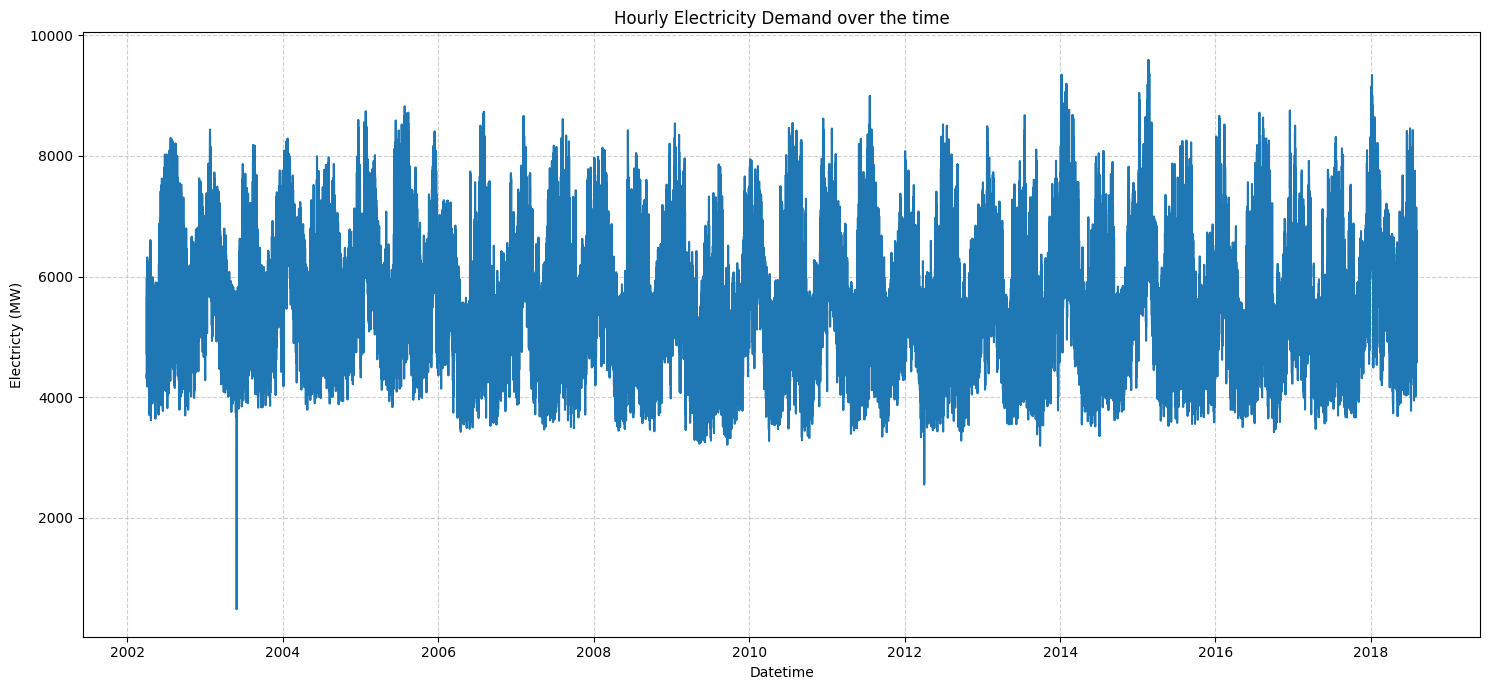

In [20]:
plt.figure(figsize = (15,7))

plt.plot(df["Datetime"],df["PJMW_MW"])
plt.title("Hourly Electricity Demand over the time")
plt.xlabel("Datetime")
plt.ylabel("Electricty (MW)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

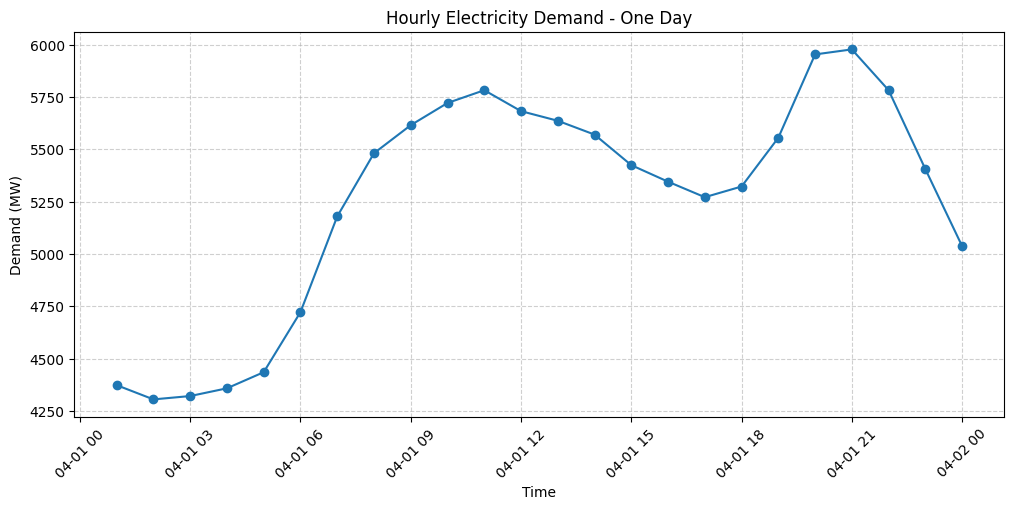

In [21]:
one_day = df.iloc[:24]

plt.figure(figsize=(12, 5))
plt.plot(one_day["Datetime"], one_day["PJMW_MW"], marker="o")

plt.title("Hourly Electricity Demand - One Day")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [22]:
df["Day"] = df["Datetime"].dt.day_name()

In [23]:
print(df[["Datetime", "Day", "PJMW_MW"]].head(10))

             Datetime     Day  PJMW_MW
0 2002-04-01 01:00:00  Monday     4374
1 2002-04-01 02:00:00  Monday     4306
2 2002-04-01 03:00:00  Monday     4322
3 2002-04-01 04:00:00  Monday     4359
4 2002-04-01 05:00:00  Monday     4436
5 2002-04-01 06:00:00  Monday     4723
6 2002-04-01 07:00:00  Monday     5180
7 2002-04-01 08:00:00  Monday     5482
8 2002-04-01 09:00:00  Monday     5616
9 2002-04-01 10:00:00  Monday     5722


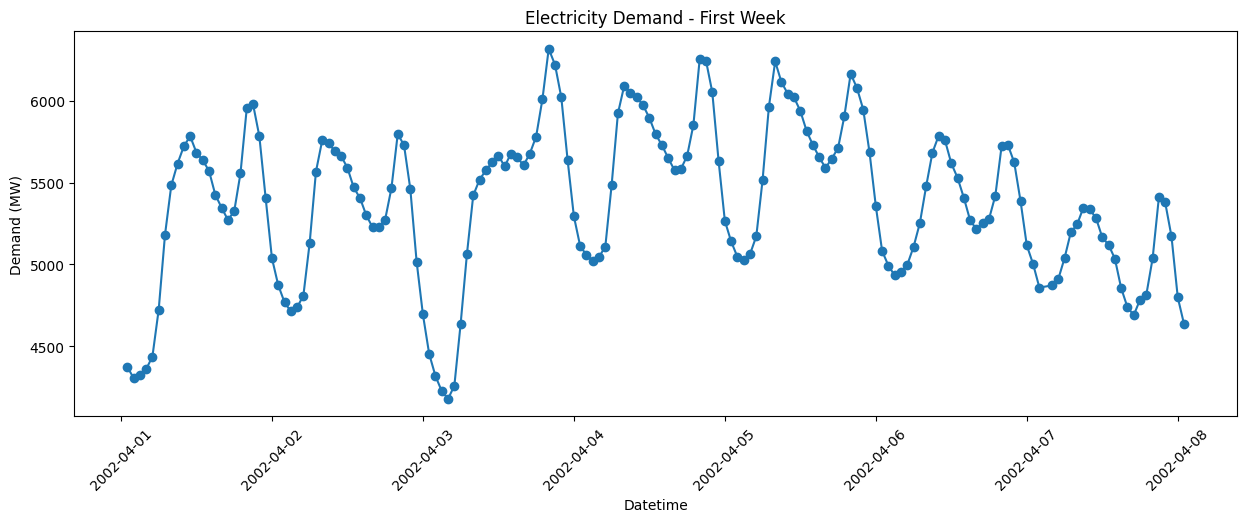

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(df.iloc[:168]["Datetime"],df.iloc[:168]["PJMW_MW"],marker="o")
plt.title("Electricity Demand - First Week")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.xticks(rotation=45)
plt.show()

In [25]:
df.groupby("Day")["PJMW_MW"].mean()

,PJMW_MW
Day,
Friday,5686.839202
Monday,5700.518783
Saturday,5293.999413
Sunday,5149.638300
Thursday,5780.841051
Tuesday,5801.076837
Wednesday,5802.370701


In [26]:
df.groupby(df["Datetime"].dt.year)["PJMW_MW"].mean()

,PJMW_MW
Datetime,
2002,5621.663180
2003,5700.628226
2004,5866.616602
2005,6038.406029
2006,5425.448847
2007,5635.396780
2008,5530.132544
2009,5290.557433
2010,5573.025351


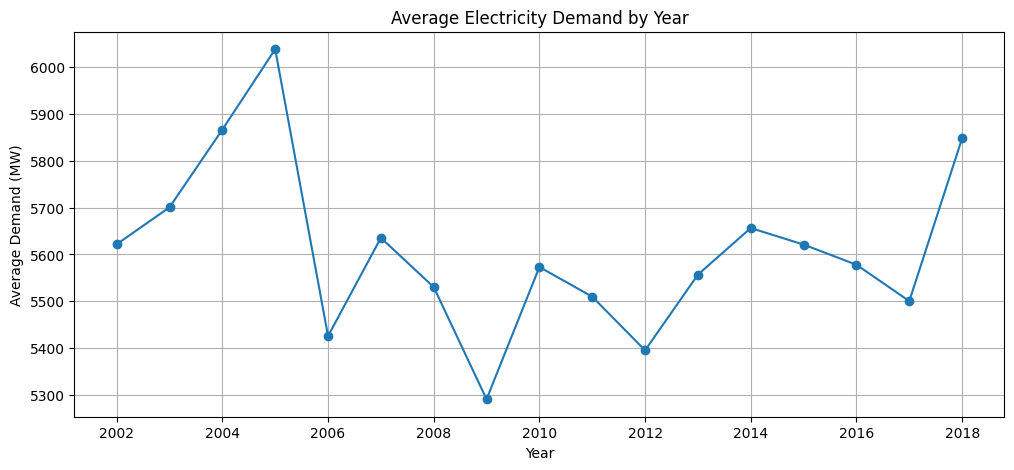

In [27]:
yearly_avg = df.groupby(df["Datetime"].dt.year)["PJMW_MW"].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker="o")

plt.title("Average Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")
plt.grid(True)

plt.show()

In [28]:
df["rolling_mean"] = df["PJMW_MW"].rolling(window=168).mean()
df["rolling_std"] = df["PJMW_MW"].rolling(window=168).std()

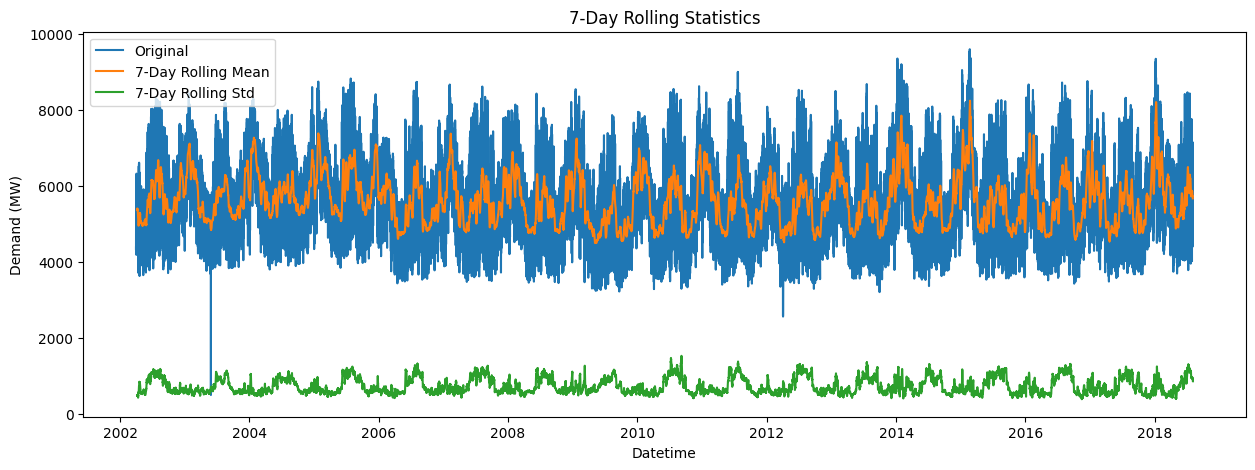

In [29]:
plt.figure(figsize=(15, 5))

plt.plot(df["Datetime"], df["PJMW_MW"], label="Original")
plt.plot(df["Datetime"], df["rolling_mean"], label="7-Day Rolling Mean")
plt.plot(df["Datetime"], df["rolling_std"], label="7-Day Rolling Std")

plt.title("7-Day Rolling Statistics")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()

In [30]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["PJMW_MW"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -19.88829608963819
p-value: 0.0


<Figure size 1500x500 with 0 Axes>

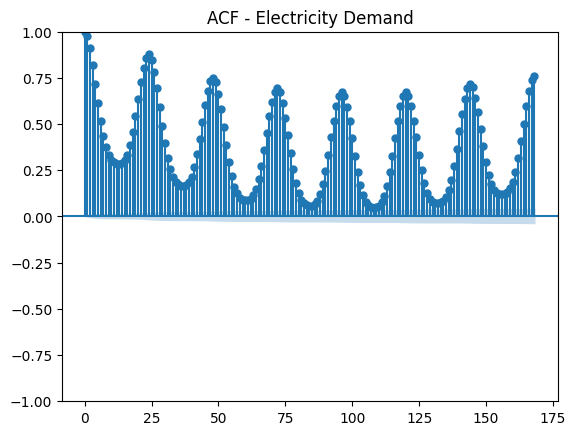

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(15, 5))

plot_acf(df["PJMW_MW"], lags=168)
plt.title("ACF - Electricity Demand")
plt.show()

<Figure size 1500x500 with 0 Axes>

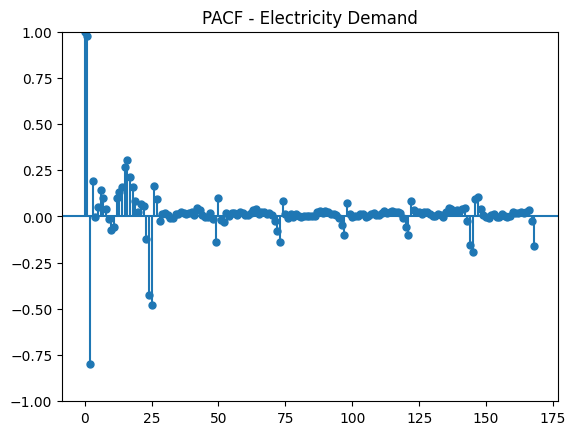

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(15, 5))

plot_pacf(df["PJMW_MW"], lags=168)
plt.title("PACF - Electricity Demand")
plt.show()

In [33]:
print(df["Datetime"].min())
print(df["Datetime"].max())

2002-04-01 01:00:00
2018-08-03 00:00:00


In [34]:
pip install holidays

In [35]:
import holidays

In [36]:
import holidays
us_holidays = holidays.US(years=range(2002, 2019))

In [37]:
holiday_dates = [
    date for date in us_holidays
    if df["Datetime"].min().date() <= date <= df["Datetime"].max().date()]

print("Number of holiday dates:", len(holiday_dates))

Number of holiday dates: 180


In [38]:
df["IsHoliday"] = df["Datetime"].dt.date.isin(holiday_dates).astype(int)

In [39]:
print(df.groupby("IsHoliday")["PJMW_MW"].mean())

IsHoliday
0    5606.281886
1    5476.773380
Name: PJMW_MW, dtype: float64


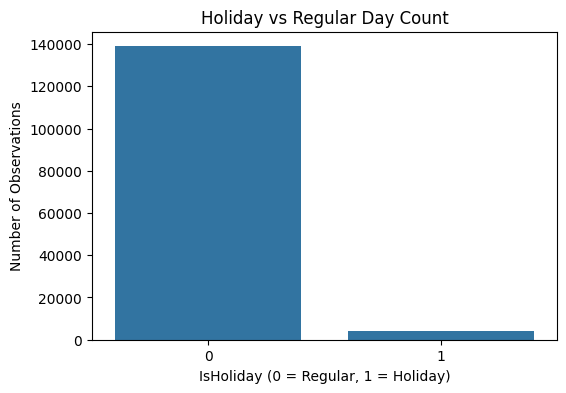

In [40]:
plt.figure(figsize=(6, 4))

sns.countplot(x='IsHoliday', data=df)

plt.title('Holiday vs Regular Day Count')
plt.xlabel('IsHoliday (0 = Regular, 1 = Holiday)')
plt.ylabel('Number of Observations')

plt.show()

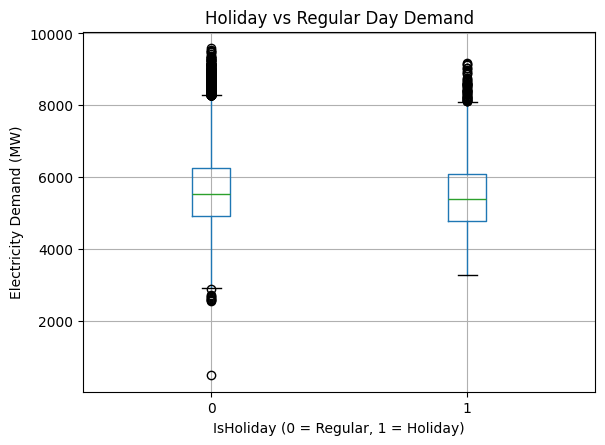

In [41]:
df.boxplot(column="PJMW_MW", by="IsHoliday")

plt.title("Holiday vs Regular Day Demand")
plt.suptitle("")
plt.xlabel("IsHoliday (0 = Regular, 1 = Holiday)")
plt.ylabel("Electricity Demand (MW)")
plt.show()

In [42]:
monthly_demand = df.groupby(df["Datetime"].dt.month)["PJMW_MW"].mean()
print(monthly_demand)

Datetime
1     6447.667759
2     6296.808813
3     5654.097376
4     5022.310855
5     5015.845746
6     5516.756046
7     5861.537081
8     5822.142809
9     5205.872049
10    4997.642155
11    5403.630372
12    6064.431236
Name: PJMW_MW, dtype: float64


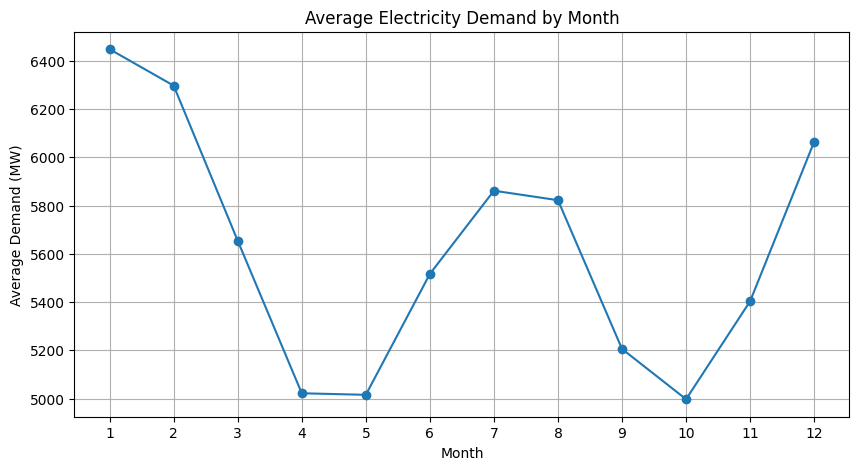

In [43]:
plt.figure(figsize=(10, 5))

monthly_demand.plot(marker="o")

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [44]:
df['Month'] = df['Datetime'].dt.month

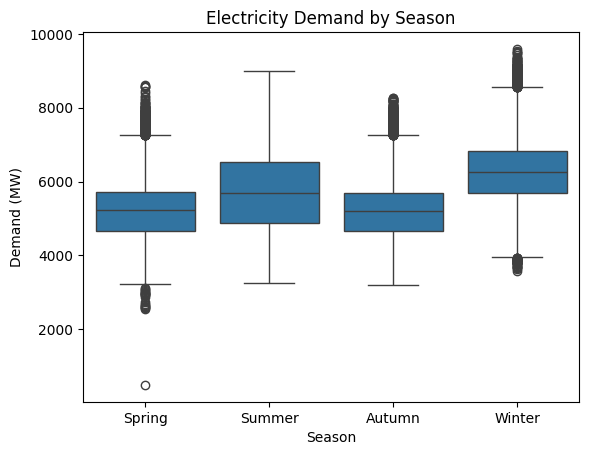

In [45]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['Season'] = df['Month'].apply(get_season)

sns.boxplot(x='Season', y='PJMW_MW', data=df)
plt.title('Electricity Demand by Season')
plt.xlabel('Season')
plt.ylabel('Demand (MW)')
plt.show()

In [46]:
Q1 = df['PJMW_MW'].quantile(0.25)
Q3 = df['PJMW_MW'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['PJMW_MW'] < lower_bound) | (df['PJMW_MW'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 4907.0
Q3: 6252.0
IQR: 1345.0
Lower Bound: 2889.5
Upper Bound: 8269.5
Number of outliers: 703


In [47]:
print("Lowest outliers:")
print(outliers[['Datetime', 'PJMW_MW']].sort_values('PJMW_MW').head(10))

print("\nHighest outliers:")
print(outliers[['Datetime', 'PJMW_MW']].sort_values('PJMW_MW', ascending=False).head(10))

Lowest outliers:
                 Datetime  PJMW_MW
10148 2003-05-29 00:00:00      487
87673 2012-04-02 00:00:00     2553
87665 2012-04-01 16:00:00     2574
87666 2012-04-01 17:00:00     2586
87667 2012-04-01 18:00:00     2600
87668 2012-04-01 19:00:00     2630
87664 2012-04-01 15:00:00     2663
87672 2012-04-01 23:00:00     2690
87663 2012-04-01 14:00:00     2721
87662 2012-04-01 13:00:00     2878

Highest outliers:
                  Datetime  PJMW_MW
112974 2015-02-20 08:00:00     9594
112962 2015-02-19 20:00:00     9536
112973 2015-02-20 07:00:00     9512
112961 2015-02-19 19:00:00     9489
112975 2015-02-20 09:00:00     9481
112963 2015-02-19 21:00:00     9424
113070 2015-02-24 08:00:00     9366
103170 2014-01-07 20:00:00     9349
138186 2018-01-05 20:00:00     9342
138185 2018-01-05 19:00:00     9325


In [48]:
print(df.loc[9977:9983, ['Datetime', 'PJMW_MW']])

                Datetime  PJMW_MW
9977 2003-05-21 21:00:00     5630
9978 2003-05-21 22:00:00     5674
9979 2003-05-21 23:00:00     5312
9980 2003-05-22 00:00:00     4882
9981 2003-05-22 01:00:00     4643
9982 2003-05-22 02:00:00     4505
9983 2003-05-22 03:00:00     4448


In [49]:
print(df.loc[87490:87510, ['Datetime', 'PJMW_MW']])

                 Datetime  PJMW_MW
87490 2012-03-25 09:00:00     4092
87491 2012-03-25 10:00:00     4318
87492 2012-03-25 11:00:00     4426
87493 2012-03-25 12:00:00     4471
87494 2012-03-25 13:00:00     4461
87495 2012-03-25 14:00:00     4412
87496 2012-03-25 15:00:00     4362
87497 2012-03-25 16:00:00     4313
87498 2012-03-25 17:00:00     4358
87499 2012-03-25 18:00:00     4473
87500 2012-03-25 19:00:00     4573
87501 2012-03-25 20:00:00     4724
87502 2012-03-25 21:00:00     4892
87503 2012-03-25 22:00:00     4715
87504 2012-03-25 23:00:00     4399
87505 2012-03-26 00:00:00     4095
87506 2012-03-26 01:00:00     3887
87507 2012-03-26 02:00:00     3745
87508 2012-03-26 03:00:00     3744
87509 2012-03-26 04:00:00     3729
87510 2012-03-26 05:00:00     3834


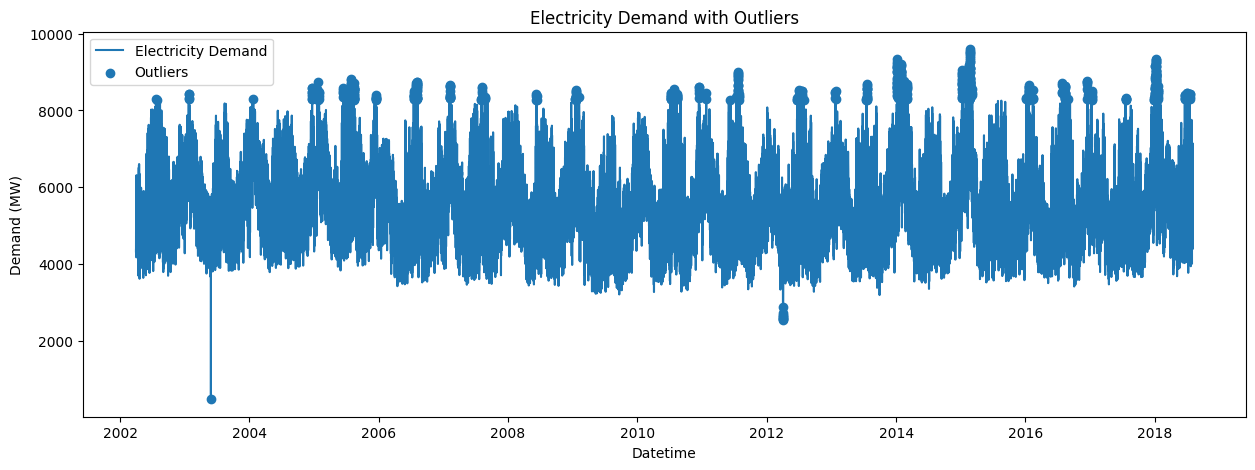

In [50]:
# Calculate IQR bounds
Q1 = df['PJMW_MW'].quantile(0.25)
Q3 = df['PJMW_MW'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['PJMW_MW'] < lower_bound) | (df['PJMW_MW'] > upper_bound)]

# Plot demand and outliers
plt.figure(figsize=(15, 5))

plt.plot(
    df['Datetime'],
    df['PJMW_MW'],
    label='Electricity Demand')

plt.scatter(
    outliers['Datetime'],
    outliers['PJMW_MW'],
    label='Outliers')

plt.title('Electricity Demand with Outliers')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

In [51]:
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Month"] = df["Datetime"].dt.month
df["Year"] = df["Datetime"].dt.year
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

In [52]:
df.head()

,Datetime,PJMW_MW,Day,rolling_mean,rolling_std,IsHoliday,Month,Season,Hour,DayOfWeek,Year,IsWeekend
0,2002-04-01 01:00:00,4374,1,NaN,NaN,0,4,Spring,1,0,2002,0
1,2002-04-01 02:00:00,4306,1,NaN,NaN,0,4,Spring,2,0,2002,0
2,2002-04-01 03:00:00,4322,1,NaN,NaN,0,4,Spring,3,0,2002,0
3,2002-04-01 04:00:00,4359,1,NaN,NaN,0,4,Spring,4,0,2002,0
4,2002-04-01 05:00:00,4436,1,NaN,NaN,0,4,Spring,5,0,2002,0


In [53]:
df["lag_1"] = df["PJMW_MW"].shift(1)
df["lag_2"] = df["PJMW_MW"].shift(2)
df["lag_3"] = df["PJMW_MW"].shift(3)

df["lag_24"] = df["PJMW_MW"].shift(24)
df["lag_48"] = df["PJMW_MW"].shift(48)

df["lag_168"] = df["PJMW_MW"].shift(168)

In [54]:
df[["Datetime", "PJMW_MW", "lag_1", "lag_24", "lag_168"]].head(30)

,Datetime,PJMW_MW,lag_1,lag_24,lag_168
0,2002-04-01 01:00:00,4374,NaN,NaN,NaN
1,2002-04-01 02:00:00,4306,4374.0,NaN,NaN
2,2002-04-01 03:00:00,4322,4306.0,NaN,NaN
3,2002-04-01 04:00:00,4359,4322.0,NaN,NaN
4,2002-04-01 05:00:00,4436,4359.0,NaN,NaN
5,2002-04-01 06:00:00,4723,4436.0,NaN,NaN
6,2002-04-01 07:00:00,5180,4723.0,NaN,NaN
7,2002-04-01 08:00:00,5482,5180.0,NaN,NaN
8,2002-04-01 09:00:00,5616,5482.0,NaN,NaN
9,2002-04-01 10:00:00,5722,5616.0,NaN,NaN


In [55]:
df["rolling_mean_24"] = df["PJMW_MW"].shift(1).rolling(24).mean()
df["rolling_mean_168"] = df["PJMW_MW"].shift(1).rolling(168).mean()

df["rolling_std_24"] = df["PJMW_MW"].shift(1).rolling(24).std()

In [56]:
df[["Datetime","PJMW_MW","rolling_mean_24","rolling_mean_168","rolling_std_24"]].head(200)

,Datetime,PJMW_MW,rolling_mean_24,rolling_mean_168,rolling_std_24
0,2002-04-01 01:00:00,4374,NaN,NaN,NaN
1,2002-04-01 02:00:00,4306,NaN,NaN,NaN
2,2002-04-01 03:00:00,4322,NaN,NaN,NaN
3,2002-04-01 04:00:00,4359,NaN,NaN,NaN
4,2002-04-01 05:00:00,4436,NaN,NaN,NaN
...,...,...,...,...,...
195,2002-04-09 05:00:00,4280,5239.625000,5371.375000,537.455423
196,2002-04-09 06:00:00,4577,5224.625000,5368.654762,559.490126
197,2002-04-09 07:00:00,5144,5209.500000,5367.273810,572.279500
198,2002-04-09 08:00:00,5374,5193.500000,5367.351190,568.342059


In [57]:
df = df.drop(columns=["rolling_mean", "rolling_std"])

In [58]:
df = df.dropna().reset_index(drop=True)

In [59]:
print(df.isnull().sum())
print(df.shape)

Datetime            0
PJMW_MW             0
Day                 0
IsHoliday           0
Month               0
Season              0
Hour                0
DayOfWeek           0
Year                0
IsWeekend           0
lag_1               0
lag_2               0
lag_3               0
lag_24              0
lag_48              0
lag_168             0
rolling_mean_24     0
rolling_mean_168    0
rolling_std_24      0
dtype: int64
(143038, 19)


In [60]:
print(df.columns)

Index(['Datetime', 'PJMW_MW', 'Day', 'IsHoliday', 'Month', 'Season', 'Hour',
       'DayOfWeek', 'Year', 'IsWeekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24',
       'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_mean_168',
       'rolling_std_24'],
      dtype='object')


In [61]:
df

,Datetime,PJMW_MW,Day,IsHoliday,Month,Season,Hour,DayOfWeek,Year,IsWeekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_mean_168,rolling_std_24
0,2002-04-08 02:00:00,4532,8,0,4,Spring,2,0,2002,0,4634.0,4798.0,5171.0,5002.0,5082.0,4374.0,5029.625000,5379.339286,234.430264
1,2002-04-08 03:00:00,4481,8,0,4,Spring,3,0,2002,0,4532.0,4634.0,4798.0,4858.0,4992.0,4306.0,5010.041667,5380.279762,255.520522
2,2002-04-08 04:00:00,4527,8,0,4,Spring,4,0,2002,0,4481.0,4532.0,4634.0,4871.0,4932.0,4322.0,4994.333333,5381.321429,276.038225
3,2002-04-08 05:00:00,4640,8,0,4,Spring,5,0,2002,0,4527.0,4481.0,4532.0,4909.0,4956.0,4359.0,4980.000000,5382.541667,291.233658
4,2002-04-08 06:00:00,4940,8,0,4,Spring,6,0,2002,0,4640.0,4527.0,4481.0,5038.0,4997.0,4436.0,4968.791667,5384.214286,299.153586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143033,2018-08-02 20:00:00,6545,2,0,8,Summer,20,3,2018,0,6693.0,6758.0,6708.0,6816.0,6276.0,7354.0,5820.541667,5681.827381,775.289117
143034,2018-08-02 21:00:00,6496,2,0,8,Summer,21,3,2018,0,6545.0,6693.0,6758.0,6571.0,6250.0,7063.0,5809.250000,5677.011905,762.020384
143035,2018-08-02 22:00:00,6325,2,0,8,Summer,22,3,2018,0,6496.0,6545.0,6693.0,6362.0,6123.0,6895.0,5806.125000,5673.636905,758.908101
143036,2018-08-02 23:00:00,5892,2,0,8,Summer,23,3,2018,0,6325.0,6496.0,6545.0,5881.0,5771.0,6255.0,5804.583333,5670.244048,757.766507


**FINAL TRAIN / TEST SPLIT**

**Last 1 year = Test Set**

In [62]:
# FINAL TRAIN / TEST SPLIT
# Last 1 year = Test Set
df = df.sort_values("Datetime").reset_index(drop=True)

last_date = df["Datetime"].max()

test_start = last_date - pd.DateOffset(years=1)

train_df = df[df["Datetime"] < test_start].copy()
test_df = df[df["Datetime"] >= test_start].copy()

print("Training period:")
print(train_df["Datetime"].min(), "to", train_df["Datetime"].max())

print("\nTesting period:")
print(test_df["Datetime"].min(), "to", test_df["Datetime"].max())

print("\nTrain rows:", len(train_df))
print("Test rows :", len(test_df))

Training period:
2002-04-08 02:00:00 to 2017-08-02 23:00:00

Testing period:
2017-08-03 00:00:00 to 2018-08-03 00:00:00

Train rows: 134277
Test rows : 8761


In [63]:
#Prepare Random Forest and XGBoost datasets
feature_cols=[
    "Hour",
    "Day",
    "DayOfWeek",
    "Month",
    "Year",
    "IsWeekend",
    "IsHoliday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24"
]

X_train = train_df[feature_cols]
y_train = train_df["PJMW_MW"]

X_test = test_df[feature_cols]
y_test = test_df["PJMW_MW"]

print(X_train.shape)
print(X_test.shape)

(134277, 16)
(8761, 16)


**Evaluation function**

In [64]:
#Before training six models, create one common evaluation function.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import pandas as pd

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }
results = []

**Model 1:-Random Forest**

In [65]:
#Train
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

#Predict
rf_pred = rf_model.predict(X_test)

#Evaluate
rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

results.append(rf_result)

rf_result

{'Model': 'Random Forest',
 'MAE': 55.32774369409104,
 'RMSE': np.float64(73.28986062107565),
 'MAPE': np.float64(0.9708186692186541),
 'R2': 0.9945603516893324}

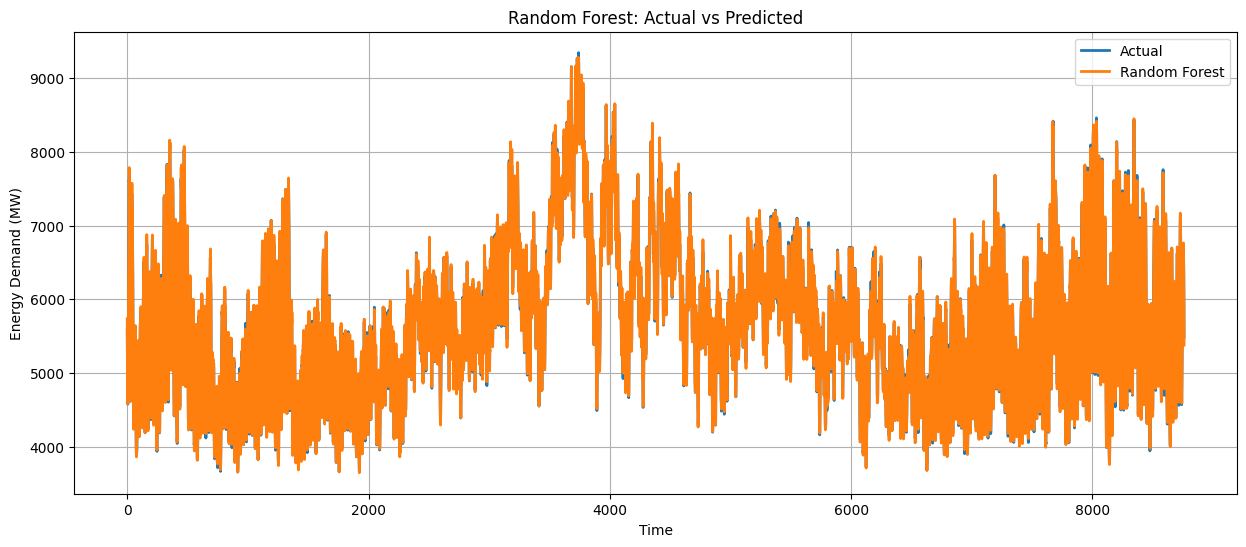

In [66]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    rf_pred,
    label="Random Forest",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

**Model 2:-XGBoost**

In [67]:
from xgboost import XGBRegressor

#Train
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

#Predict
xgb_pred = xgb_model.predict(X_test)

#Evaluate
xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

results.append(xgb_result)

xgb_result

{'Model': 'XGBoost',
 'MAE': 52.94877243041992,
 'RMSE': np.float64(70.879515811825),
 'MAPE': np.float64(0.9206868022808398),
 'R2': 0.9949122667312622}

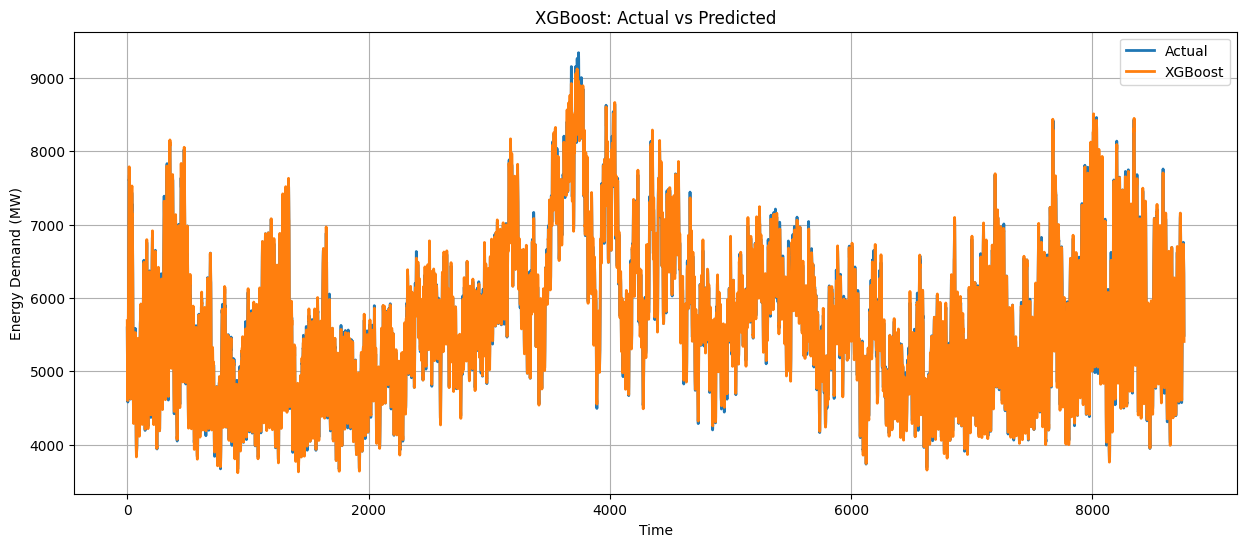

In [68]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    xgb_pred,
    label="XGBoost",
    linewidth=2
)

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [69]:
#Compare Random Forest and XGBoost
comparison = pd.DataFrame(results)

comparison.sort_values(
    by="RMSE",
    ascending=True,
    ignore_index=True
)

,Model,MAE,RMSE,MAPE,R2
0,XGBoost,52.948772,70.879516,0.920687,0.994912
1,Random Forest,55.327744,73.289861,0.970819,0.994560


Lower MAE, RMSE and MAPE indicate better forecasting performance, while higher R² indicates that the model explains more variation in electricity demand.

In [70]:
train_series = train_df.set_index("Datetime")["PJMW_MW"]
test_series = test_df.set_index("Datetime")["PJMW_MW"]

In [71]:
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

**Model 3 :- ARIMA**

In [72]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Prepare the time-series data
train_series = train_df["PJMW_MW"].astype(float).reset_index(drop=True)
test_series = test_df["PJMW_MW"].astype(float).reset_index(drop=True)

# order = (p, d, q)
# p = 2
# d = 0
# q = 2
arima_model = ARIMA(
    train_series,
    order=(5,1,1)
)

# Fit model
arima_fit = arima_model.fit()


# Forecast

arima_pred = arima_fit.forecast(
    steps=len(test_series)
)

# Convert predictions to NumPy array
arima_pred = arima_pred.to_numpy()


# Evaluate
arima_result = evaluate_model(
    "ARIMA",
    test_series.to_numpy(),
    arima_pred
)

# Add result
results.append(arima_result)

# Display result
arima_result

{'Model': 'ARIMA',
 'MAE': 942.014326368379,
 'RMSE': np.float64(1131.3492264914207),
 'MAPE': np.float64(18.182753349345035),
 'R2': -0.2962130787436643}

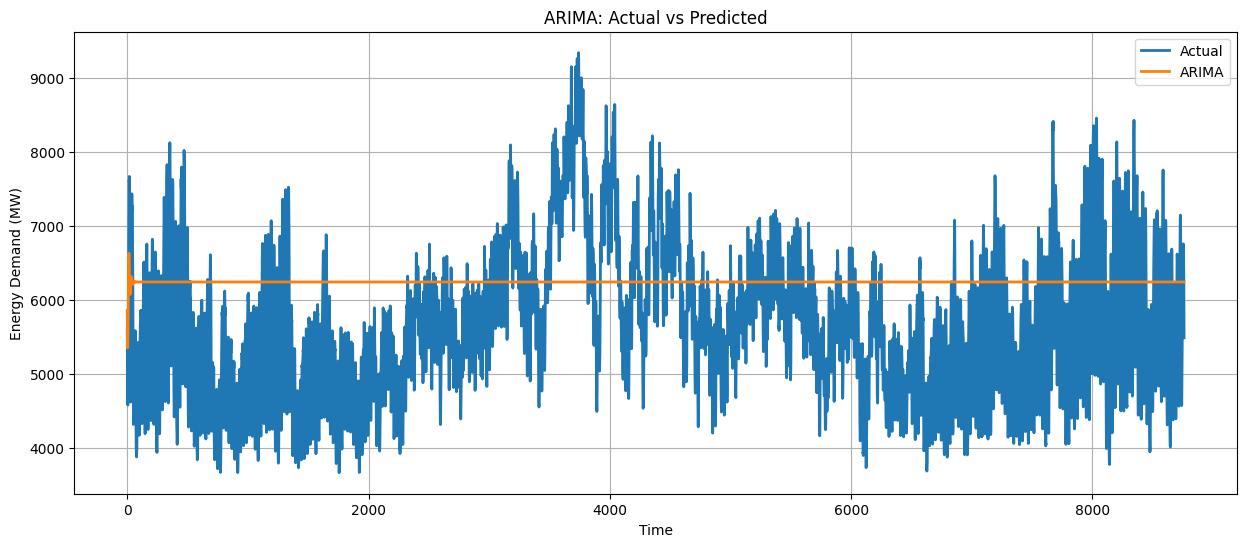

In [73]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    test_series.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    arima_pred,
    label="ARIMA",
    linewidth=2
)

plt.title("ARIMA: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

**Model 4: SARIMAX**

In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Take only the last 8 years of hourly training data
train_series_8y = train_series.iloc[-70080:]

print("Training observations:", len(train_series_8y))
start_date = train_df.iloc[train_series_8y.index.min()]['Datetime']
end_date = train_df.iloc[train_series_8y.index.max()]['Datetime']

print("Start Date:", start_date.strftime("%Y-%m-%d"))
print("End Date:", end_date.strftime("%Y-%m-%d"))

# Build SARIMAX model
sarimax_model = SARIMAX(
    train_series_8y,
    order=(1,1,2),
    seasonal_order=(1,1,0,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

# Fit model
sarimax_fit = sarimax_model.fit(
    disp=False,
    maxiter=50
)

# Forecast
sarimax_pred = sarimax_fit.forecast(
    steps=len(test_series)
)

# Evaluation
sarimax_result = evaluate_model(
    "SARIMAX (8 Years)",
    test_series.values,
    sarimax_pred.values
)

results.append(sarimax_result)

Training observations: 70080
Start Date: 2009-08-04
End Date: 2017-08-02


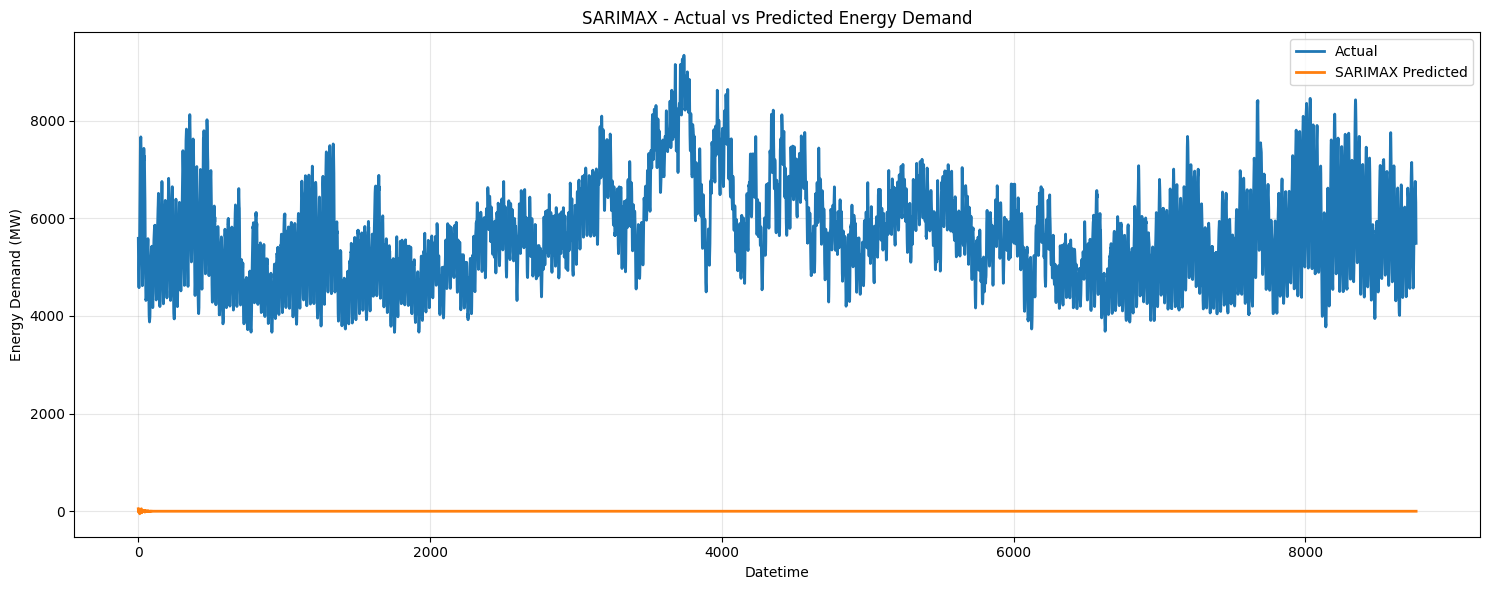

In [76]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    test_series.index,
    test_series.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_series.index,
    sarimax_pred.values,
    label="SARIMAX Predicted",
    linewidth=2
)

plt.title("SARIMAX - Actual vs Predicted Energy Demand")
plt.xlabel("Datetime")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Model:-5 RNN**

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import numpy as np

# Create sequences
time_steps = 24

X_train_rnn = []
y_train_rnn = []

for i in range(time_steps, len(X_train)):
    X_train_rnn.append(X_train[i-time_steps:i])
    y_train_rnn.append(y_train.iloc[i] if hasattr(y_train, "iloc") else y_train[i])

X_test_rnn = []
y_test_rnn = []

for i in range(time_steps, len(X_test)):
    X_test_rnn.append(X_test[i-time_steps:i])
    y_test_rnn.append(y_test.iloc[i] if hasattr(y_test, "iloc") else y_test[i])

X_train_rnn = np.array(X_train_rnn)
y_train_rnn = np.array(y_train_rnn)

X_test_rnn = np.array(X_test_rnn)
y_test_rnn = np.array(y_test_rnn)

# Build RNN model
rnn_model = Sequential([
    SimpleRNN(
        64,
        activation="tanh",
        input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])
    ),
    Dense(1)
])

# Compile
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# Train
rnn_model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict
rnn_pred = rnn_model.predict(X_test_rnn).flatten()

# Evaluate
rnn_result = evaluate_model(
    "RNN",
    y_test_rnn,
    rnn_pred
)

results.append(rnn_result)

Epoch 1/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 30749572.0000
Epoch 2/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - loss: 27877296.0000
Epoch 3/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 25157248.0000
Epoch 4/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - loss: 22582894.0000
Epoch 5/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - loss: 20156694.0000
Epoch 6/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - loss: 17875342.0000
Epoch 7/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - loss: 15742340.0000
Epoch 8/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - loss: 13754443.0000
Epoch 9/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 52s 12ms/step - loss: 11912826.0000
Epoch 10/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - loss: 10217051.0000
Epoch 11/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - loss: 8667056.0000
Epoch 12/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - loss: 7261407.0000
Epoch 13/20
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - loss: 6001877.50

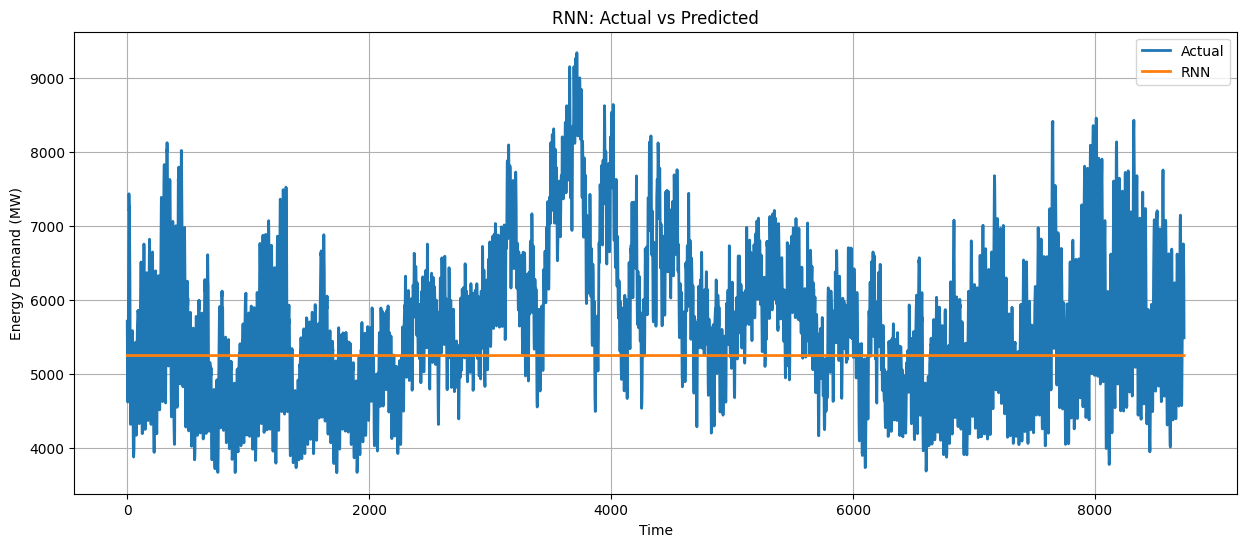

In [78]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    y_test_rnn,
    label="Actual",
    linewidth=2
)

plt.plot(
    rnn_pred,
    label="RNN",
    linewidth=2
)

plt.title("RNN: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

**Model:-6 LSTM**

In [79]:
!pip install tensorflow

In [80]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [81]:
#LSTM preprocessing
scaler = MinMaxScaler()

train_values = train_df["PJMW_MW"].values.reshape(-1, 1)

scaled_train = scaler.fit_transform(
    train_values
)
LOOKBACK = 168

#Function:
def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(lookback, len(data)):

        X.append(
            data[i-lookback:i, 0]
        )

        y.append(
            data[i, 0]
        )

    X = np.array(X)
    y = np.array(y)

    return X, y

X_lstm_train, y_lstm_train = create_sequences(
    scaled_train,
    LOOKBACK
)

X_lstm_train = X_lstm_train.reshape(
    X_lstm_train.shape[0],
    X_lstm_train.shape[1],
    1
)

In [82]:
#Build the LSTM
lstm_model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 218s 220ms/step - loss: 0.0119 - val_loss: 0.0037
Epoch 2/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 177s 188ms/step - loss: 0.0057 - val_loss: 0.0016
Epoch 3/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 178s 189ms/step - loss: 0.0028 - val_loss: 0.0010
Epoch 4/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 182s 193ms/step - loss: 0.0015 - val_loss: 4.9555e-04
Epoch 5/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 184s 195ms/step - loss: 7.7289e-04 - val_loss: 3.5256e-04
Epoch 6/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 203s 196ms/step - loss: 5.7581e-04 - val_loss: 2.8057e-04
Epoch 7/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 182s 193ms/step - loss: 4.9924e-04 - val_loss: 2.1669e-04
Epoch 8/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 184s 195ms/step - loss: 4.4389e-04 - val_loss: 1.9809e-04
Epoch 9/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 183s 194ms/step - loss: 4.2179e-04 - val_loss: 2.9925e-04
Epoch 10/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 188s 199ms/step - loss: 4.0984e-04 - val_loss: 1.5864e-04
Epoch 11/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 195s 1

In [83]:
#LSTM test prediction
combined = pd.concat([
    train_df[["Datetime", "PJMW_MW"]],
    test_df[["Datetime", "PJMW_MW"]]
])

combined_values = combined["PJMW_MW"].values.reshape(-1, 1)

combined_scaled = scaler.transform(
    combined_values
)

In [84]:
test_start_index = len(train_df)
lstm_inputs = combined_scaled[
    test_start_index - LOOKBACK:
]

X_lstm_test = []

for i in range(
    LOOKBACK,
    len(lstm_inputs)
):
    X_lstm_test.append(
        lstm_inputs[i-LOOKBACK:i, 0]
    )

X_lstm_test = np.array(X_lstm_test)

X_lstm_test = X_lstm_test.reshape(
    X_lstm_test.shape[0],
    X_lstm_test.shape[1],
    1
)

# Predict
lstm_pred_scaled = lstm_model.predict(
    X_lstm_test
)

# Convert back: inverse the scaling to get MW units
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

# Evaluate
lstm_result = evaluate_model(
    "LSTM",
    test_df["PJMW_MW"].values,
    lstm_pred
)

results.append(lstm_result)

lstm_result

274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step


{'Model': 'LSTM',
 'MAE': 78.4755859375,
 'RMSE': np.float64(100.84820450341444),
 'MAPE': np.float64(1.4000392501390666),
 'R2': 0.989700436592102}

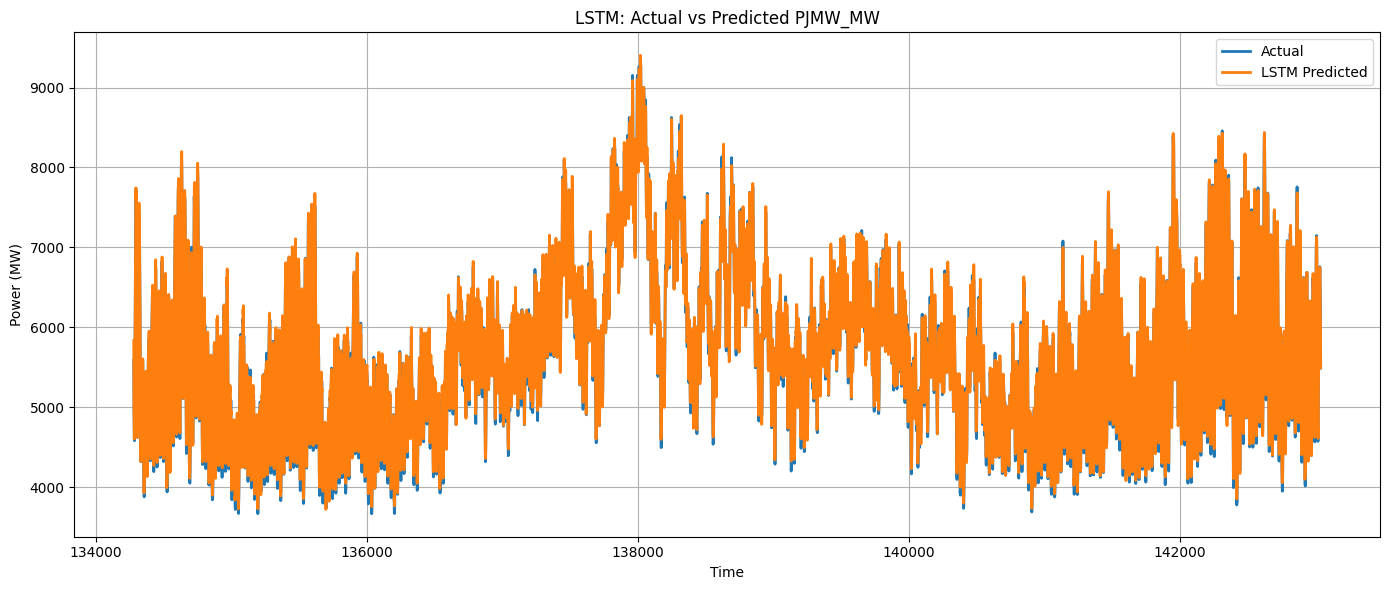

In [85]:
#Plot actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_df.index,
    test_df["PJMW_MW"].values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_df.index,
    lstm_pred,
    label="LSTM Predicted",
    linewidth=2
)

plt.title("LSTM: Actual vs Predicted PJMW_MW")
plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Model 7:- Gradient Boosting Regressor**

In [86]:
from sklearn.ensemble import GradientBoostingRegressor

# Train Model
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Predictions
gb_pred = gb_model.predict(X_test)

# Evaluate
gb_result = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

results.append(gb_result)

gb_result

{'Model': 'Gradient Boosting',
 'MAE': 53.98105794207898,
 'RMSE': np.float64(69.74539963610843),
 'MAPE': np.float64(0.9500683006502499),
 'R2': 0.9950737758968707}

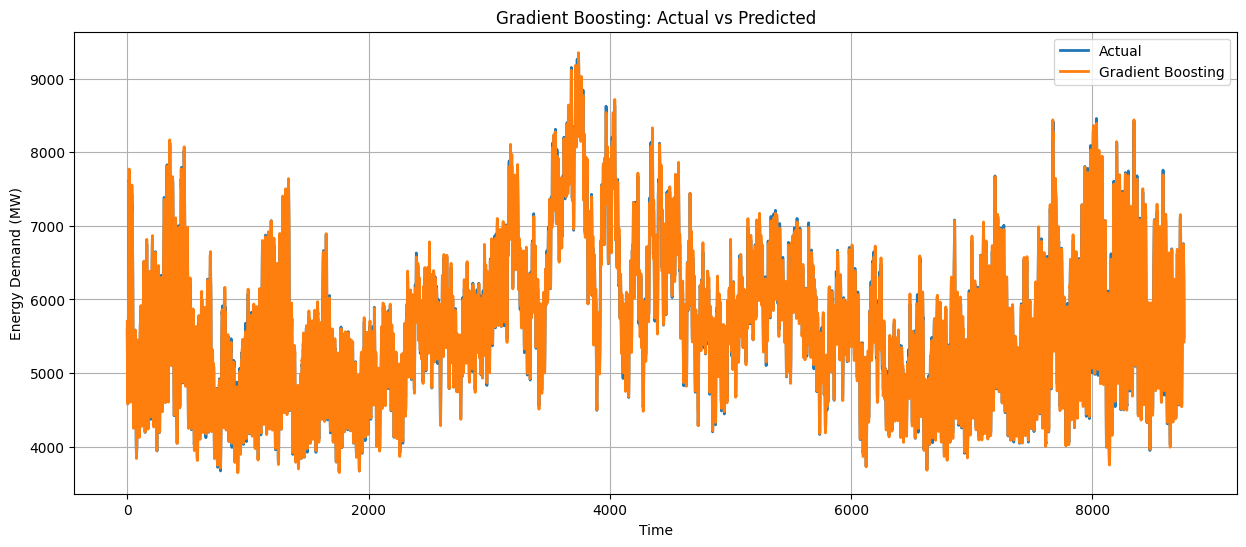

In [105]:
#Plot actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    gb_pred,
    label="Gradient Boosting",
    linewidth=2
)

plt.title("Gradient Boosting: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

**Model's Comparison**

In [87]:
#Create final model comparison
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,MAPE,R2
0,Gradient Boosting,53.981058,69.745400,0.950068,0.995074
1,XGBoost,52.948772,70.879516,0.920687,0.994912
2,Random Forest,55.327744,73.289861,0.970819,0.994560
3,LSTM,78.475586,100.848205,1.400039,0.989700
4,RNN,839.694580,1090.476157,14.020232,-0.205842
5,ARIMA,942.014326,1131.349226,18.182753,-0.296213
6,SARIMAX (8 Years),5700.816113,5786.774482,99.999820,-32.912214


XGBoost was selected as the best model because it achieved the lowest MAE (52.95 MW) and the lowest MAPE (0.92%) among all the evaluated models, indicating highly accurate predictions. It also achieved an excellent RMSE of 70.88 MW and an R² score of 0.9949, showing that it explains nearly 99.5% of the variation in the actual power demand. Although Gradient Boosting had a slightly lower RMSE and higher R², XGBoost provided the lowest overall prediction errors. Therefore, XGBoost was selected as the final forecasting model due to its strong accuracy and consistent performance compared with the other models.


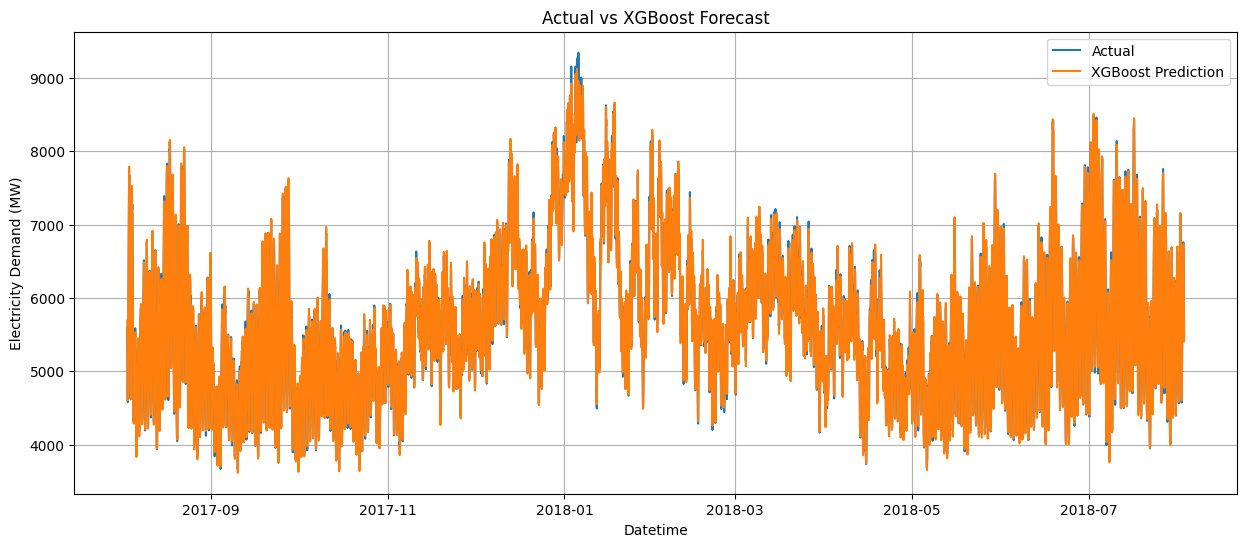

In [88]:
# Best Model's Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    test_df["Datetime"],
    y_test,
    label="Actual"
)

plt.plot(
    test_df["Datetime"],
    xgb_pred,
    label="XGBoost Prediction"
)

plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.title("Actual vs XGBoost Forecast")

plt.legend()
plt.grid(True)

plt.show()

In [89]:
best_pred = xgb_pred

In [90]:
residuals = y_test.values - best_pred

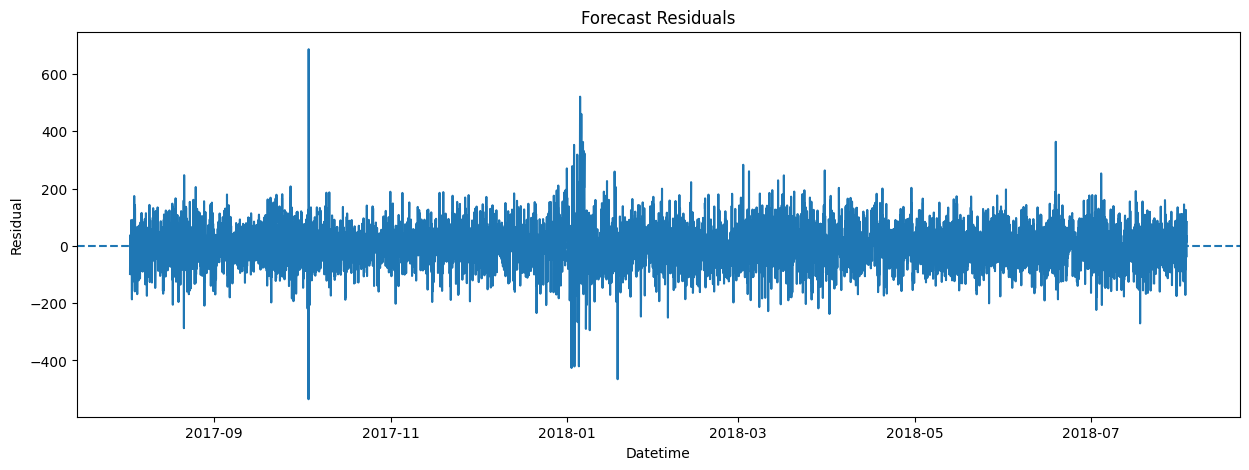

In [91]:
plt.figure(figsize=(15,5))

plt.plot(
    test_df["Datetime"],
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Forecast Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")

plt.show()

In [92]:
#Feature importance for XGBoost
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
7,lag_1,0.405675
8,lag_2,0.322448
10,lag_24,0.154065
9,lag_3,0.032692
0,Hour,0.023677
12,lag_168,0.022043
2,DayOfWeek,0.013238
5,IsWeekend,0.010285
13,rolling_mean_24,0.007053
15,rolling_std_24,0.003330


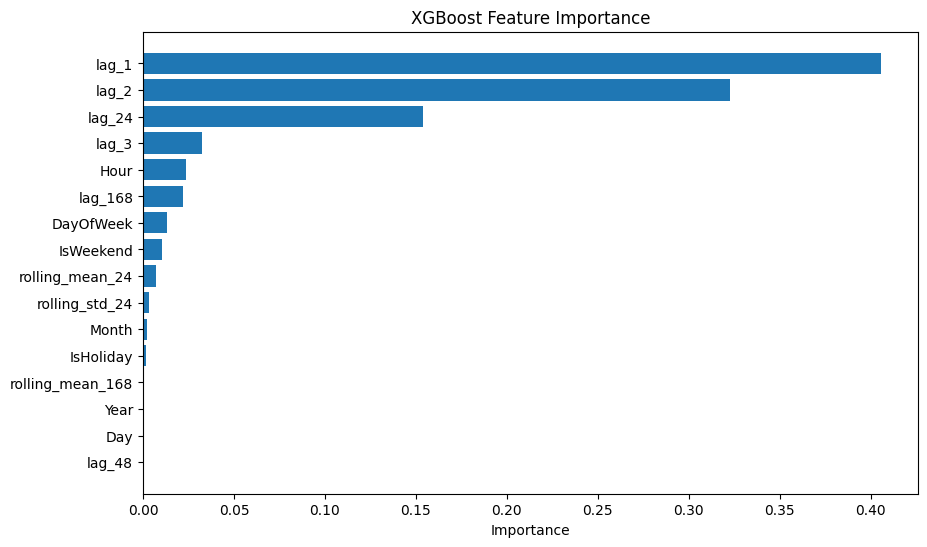

In [93]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

In [94]:
#30-day recursive forecast for XGBoost
history_df = df.copy()

history_df = history_df.sort_values(
    "Datetime"
).reset_index(drop=True)

In [95]:
#Create a function to calculate features for one timestamp:-
def create_future_features(history):

    row = {}

    current_time = history["Datetime"].iloc[-1] + pd.Timedelta(hours=1)

    row["Hour"] = current_time.hour
    row["Day"] = current_time.day
    row["DayOfWeek"] = current_time.dayofweek
    row["Month"] = current_time.month
    row["Year"] = current_time.year
    row["IsWeekend"] = int(
        current_time.dayofweek in [5, 6]
    )

    row["IsHoliday"] = int(
        current_time.date() in holiday_dates
    )

    row["lag_1"] = history["PJMW_MW"].iloc[-1]
    row["lag_2"] = history["PJMW_MW"].iloc[-2]
    row["lag_3"] = history["PJMW_MW"].iloc[-3]

    row["lag_24"] = history["PJMW_MW"].iloc[-24]
    row["lag_48"] = history["PJMW_MW"].iloc[-48]
    row["lag_168"] = history["PJMW_MW"].iloc[-168]

    row["rolling_mean_24"] = (
        history["PJMW_MW"]
        .iloc[-24:]
        .mean()
    )

    row["rolling_mean_168"] = (
        history["PJMW_MW"]
        .iloc[-168:]
        .mean()
    )

    row["rolling_std_24"] = (
        history["PJMW_MW"]
        .iloc[-24:]
        .std()
    )

    return pd.DataFrame([row]), current_time

In [96]:
future_predictions = []

future_history = history_df[
    ["Datetime", "PJMW_MW"]
].copy()

for i in range(720):

    X_future, future_time = create_future_features(
        future_history
    )

    prediction = xgb_model.predict(
        X_future[feature_cols]
    )[0]

    future_predictions.append({
        "Datetime": future_time,
        "Predicted_MW": prediction
    })

    future_history = pd.concat([
        future_history,
        pd.DataFrame({
            "Datetime": [future_time],
            "PJMW_MW": [prediction]
        })
    ], ignore_index=True)

In [97]:
#Final DataFrame:-
future_forecast = pd.DataFrame(
    future_predictions
)

future_forecast.head()

,Datetime,Predicted_MW
0,2018-08-03 01:00:00,5076.455078
1,2018-08-03 02:00:00,4818.661621
2,2018-08-03 03:00:00,4652.062500
3,2018-08-03 04:00:00,4554.975098
4,2018-08-03 05:00:00,4578.772949


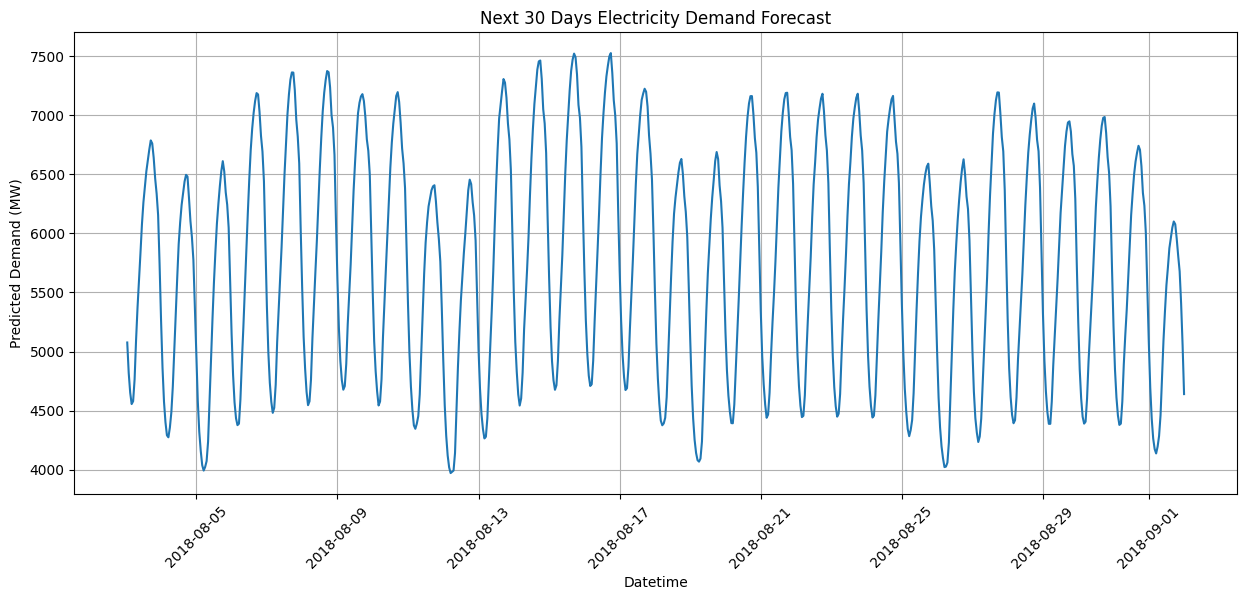

In [98]:
#Plot 30-day forecast
plt.figure(figsize=(15,6))

plt.plot(
    future_forecast["Datetime"],
    future_forecast["Predicted_MW"]
)

plt.title(
    "Next 30 Days Electricity Demand Forecast"
)

plt.xlabel("Datetime")
plt.ylabel("Predicted Demand (MW)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [99]:
# Save forecast CSV
future_forecast.to_csv(
    "next_30_days_forecast.csv",
    index=False
)

In [100]:
#PJM dataset is U.S. electricity demand data, so use U.S. holidays:
# Get the years present in your dataset
start_year = df["Datetime"].dt.year.min()
end_year = df["Datetime"].dt.year.max()

# Create US holiday calendar
us_holidays = holidays.US(
    years=range(start_year, end_year + 1)
)

# Convert holiday dates to a set
holiday_dates = set(us_holidays.keys())

print("Number of holidays:", len(holiday_dates))

# Display some holidays
for date in sorted(holiday_dates)[:20]:
    print(date, us_holidays.get(date))


#Saving the hoilday_dates
import joblib
joblib.dump(
    holiday_dates,
    "holiday_dates.pkl"
)

print("holiday_dates.pkl saved successfully")

Number of holidays: 189
2002-01-01 New Year's Day
2002-01-21 Martin Luther King Jr. Day
2002-02-18 Washington's Birthday
2002-05-27 Memorial Day
2002-07-04 Independence Day
2002-09-02 Labor Day
2002-10-14 Columbus Day
2002-11-11 Veterans Day
2002-11-28 Thanksgiving Day
2002-12-25 Christmas Day
2003-01-01 New Year's Day
2003-01-20 Martin Luther King Jr. Day
2003-02-17 Washington's Birthday
2003-05-26 Memorial Day
2003-07-04 Independence Day
2003-09-01 Labor Day
2003-10-13 Columbus Day
2003-11-11 Veterans Day
2003-11-27 Thanksgiving Day
2003-12-25 Christmas Day
holiday_dates.pkl saved successfully


In [101]:
#Saving the Best Model
import joblib

joblib.dump(
    xgb_model,
    "xgb_model.pkl"
)

['xgb_model.pkl']

In [102]:
#Saving your feature list too:
joblib.dump(
    feature_cols,
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [103]:
#Save the comparison table
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

In [104]:
#Save the dataset information
metadata = {
    "target": "PJMW_MW",
    "frequency": "Hourly",
    "forecast_horizon_days": 30,
    "forecast_horizon_hours": 720,
    "best_model": "XGBoost"
}

joblib.dump(
    metadata,
    "metadata.pkl"
)

['metadata.pkl']